# COCO 2017 Dataset Exploratory Data Analysis

The COCO (Common Objects in Context) dataset is a large-scale image recognition dataset used for various computer vision tasks like object detection, segmentation, and captioning. It contains over 330,000 images, each annotated with 80 object categories and 5 captions describing the scene.

COCO is benchmark dataset commonly used in machine learning—both for research and practical applications.

Overview of COCO 2017 dataset is given in [this blogpost](https://www.v7labs.com/blog/coco-dataset-guide) and in [paper 'Microsoft COCO: Common Objects in Context'](https://arxiv.org/abs/1405.0312).

In [1]:
from preprocess.preprocess import read_dataset
from utils.config import *
from utils.utils import *
import json
import statistics

### Train Annotations Info

In [2]:
with open(captions_train_path, 'r') as file:
    train_ann = json.load(file)

In [3]:
train_ann.keys()

dict_keys(['info', 'licenses', 'images', 'annotations'])

In [4]:
train_ann['info']

{'description': 'COCO 2017 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2017,
 'contributor': 'COCO Consortium',
 'date_created': '2017/09/01'}

In [5]:
len(train_ann['images'])

118287

In [6]:
len(train_ann['annotations'])

591753

In [7]:
print(f'There are {len(train_ann["images"])} images and {len(train_ann["annotations"])} captions in training dataset.')

There are 118287 images and 591753 captions in training dataset.


In [8]:
train_ann['images'][0]

{'license': 3,
 'file_name': '000000391895.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'height': 360,
 'width': 640,
 'date_captured': '2013-11-14 11:18:45',
 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
 'id': 391895}

In [9]:
train_ann['annotations'][0]

{'image_id': 203564,
 'id': 37,
 'caption': 'A bicycle replica with a clock as the front wheel.'}

In [10]:
image_height = [train_ann['images'][i]['height'] for i in range(len(train_ann['images']))]

In [11]:
print('Minimum image height:', min(image_height))
print('Maximum image height:', max(image_height))

Minimum image height: 51
Maximum image height: 640


In [12]:
print('Mean image height:', statistics.mean(image_height))
print('Median image height:', statistics.median(image_height))
print('Standard deviation image height:', statistics.stdev(image_height))

Mean image height: 484.09889506031936
Median image height: 480
Standard deviation image height: 97.08957287350368


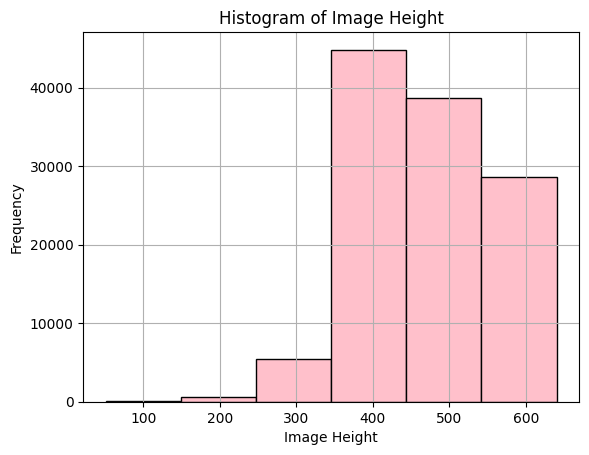

In [13]:
import matplotlib.pyplot as plt

plt.hist(image_height, bins=6, color='pink', edgecolor='black')
plt.xlabel('Image Height')
plt.ylabel('Frequency')
plt.title('Histogram of Image Height')
plt.grid(True)
plt.show()

In [14]:
image_width = [train_ann['images'][i]['width'] for i in range(len(train_ann['images']))]

In [15]:
print('Minimum image width:', min(image_width))
print('Maximum image width:', max(image_width))

Minimum image width: 59
Maximum image width: 640


In [16]:
print('Mean image width:', statistics.mean(image_width))
print('Median image width:', statistics.median(image_width))
print('Standard deviation image width:', statistics.stdev(image_width))

Mean image width: 577.7120647239342
Median image width: 640
Standard deviation image width: 91.88434028911564


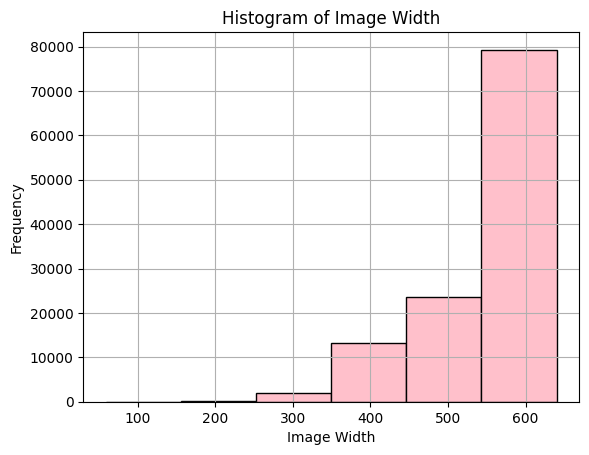

In [17]:
plt.hist(image_width, bins=6, color='pink', edgecolor='black')
plt.xlabel('Image Width')
plt.ylabel('Frequency')
plt.title('Histogram of Image Width')
plt.grid(True)

In [18]:
train_imgs_ids = [train_ann['images'][i]['id'] for i in range(len(train_ann['images']))]

min(train_imgs_ids), max(train_imgs_ids)

(9, 581929)

### Validation Annotations Info

In [19]:
captions_val_path = r'C:\Users\HP\AndjaDenic\ImageCaptioning\data\captions_val2017.json'

In [20]:
with open(captions_val_path, 'r') as file:
    val_ann = json.load(file)

In [21]:
val_ann.keys()

dict_keys(['info', 'licenses', 'images', 'annotations'])

In [22]:
val_ann['info']

{'description': 'COCO 2017 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2017,
 'contributor': 'COCO Consortium',
 'date_created': '2017/09/01'}

In [23]:
len(val_ann['images'])

5000

In [24]:
len(val_ann['annotations'])

25014

In [25]:
print(f'There are {len(val_ann["images"])} images and {len(val_ann["annotations"])} captions in validation dataset.')

There are 5000 images and 25014 captions in validation dataset.


### Display Images from Train Dataset with Captions

A single image has numerous different options for caption. In miniCOCO dataset 5 captions are assigned to each image manually.

We will pick a few images from train dataset and display them with annotated captions.

In [26]:
train_dataset_dict = read_dataset(train_dataset_json)

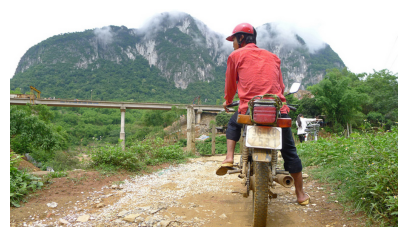

In [27]:
display_image(train_dataset_dict[0]['img_path'])

In [28]:
train_dataset_dict[0]['captions']

['A man with a red helmet on a small moped on a dirt road. ',
 'Man riding a motor bike on a dirt road on the countryside.',
 'A man riding on the back of a motorcycle.',
 'A dirt path with a young person on a motor bike rests to the foreground of a verdant area with a bridge and a background of cloud-wreathed mountains. ',
 'A man in a red shirt and a red hat is on a motorcycle on a hill side.']

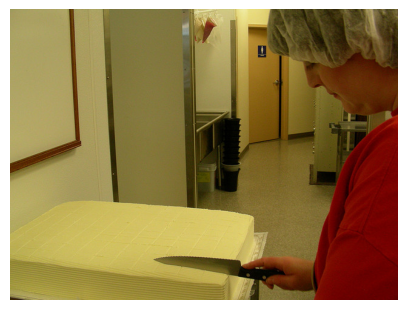

In [29]:
display_image(train_dataset_dict[1]['img_path'])

In [30]:
train_dataset_dict[1]['captions']

['A woman wearing a net on her head cutting a cake. ',
 'A woman cutting a large white sheet cake.',
 'A woman wearing a hair net cutting a large sheet cake.',
 'there is a woman that is cutting a white cake',
 "A woman marking a cake with the back of a chef's knife. "]

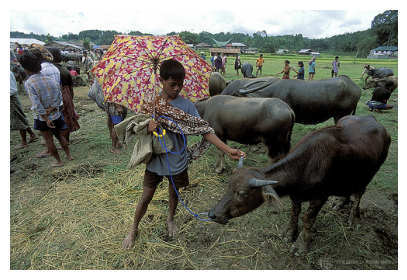

In [31]:
display_image(train_dataset_dict[2]['img_path'])

In [32]:
train_dataset_dict[3]['captions']

['A young boy standing in front of a computer keyboard.',
 'a little boy wearing headphones and looking at a computer monitor',
 'He is listening intently to the computer at school.',
 'A young boy stares up at the computer monitor.',
 'a young kid with head phones on using a computer ']

### Nuber of descriptions per image

In [33]:
freq = [len(train_dataset_dict[i]['captions']) for i in range(len(train_dataset_dict))]

In [34]:
print('Minimum number of descriptions per image:', min(freq))
print('Maximum number of descriptions per image:', max(freq))
print('Mean number of descriptions per image:', statistics.mean(freq))
print('Median number of descriptions per image:', statistics.median(freq))
print('Standard deviation number of descriptions per image:', statistics.stdev(freq))

Minimum number of descriptions per image: 5
Maximum number of descriptions per image: 7
Mean number of descriptions per image: 5.002688376575617
Median number of descriptions per image: 5
Standard deviation number of descriptions per image: 0.05226754622926526


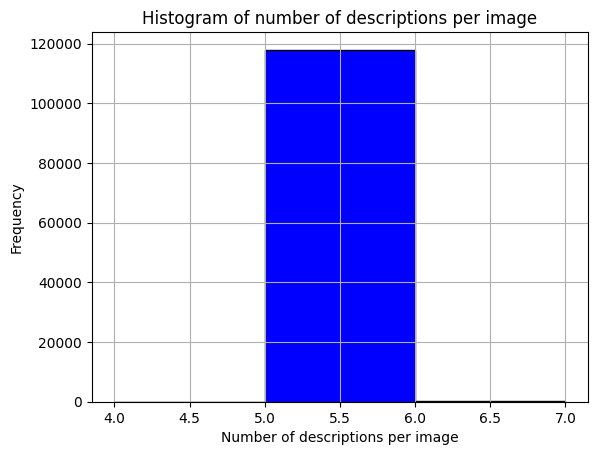

In [35]:
import matplotlib.pyplot as plt

plt.hist(freq, bins=[4, 5, 6, 7], color='blue', edgecolor='black')
plt.xlabel('Number of descriptions per image')
plt.ylabel('Frequency')
plt.title('Histogram of number of descriptions per image')
plt.grid(True)
plt.show()

In [36]:
print(f'Number of images that have 5 captions: {len([1 for x in freq if x == 5])}')
print(f'Number of images that have 6 captions: {len([1 for x in freq if x == 6])}.')
print(f'Number of images that have 7 captions: {len([1 for x in freq if x == 7])}.')

Number of images that have 5 captions: 117972
Number of images that have 6 captions: 312.
Number of images that have 7 captions: 3.


### Vocabulary

In [53]:
from preprocess.preprocess import *

In [54]:
vocabulary = Vocabulary()
vocabulary.load_vocab(vocab_json)

Vocabulary successfully loaded.


In [55]:
print(f'Vocabulary has {len(vocabulary)} words.')

Vocabulary has 29077 words.


### Number of words (tokens) per caption

In [56]:
train_dataset_1c = CocoDataset1c(data_path=train_data_path,
                                 dataset_1c_path=train_dataset_1c_json,
                                 vocabulary=vocabulary).to(device)

AttributeError: 'CocoDataset1c' object has no attribute 'to'

In [39]:
len_caption = [train_dataset_1c[i]['length_tensor'].item() for i in range(len(train_dataset_1c))]

In [45]:
print('Minimum number of words per caption:', min(len_caption))
print('Maximum number of words per caption:', max(len_caption))
print('Mean number of words per caption:', statistics.mean(len_caption))
print('Median number of words per caption:', statistics.median(len_caption))
print('Standard deviation of number of words per caption:', statistics.stdev(len_caption))

Minimum number of words per caption: 5
Maximum number of words per caption: 49
Mean number of words per caption: 10.455004030397818
Median number of words per caption: 10
Standard deviation of number of words per caption: 2.392075609509882


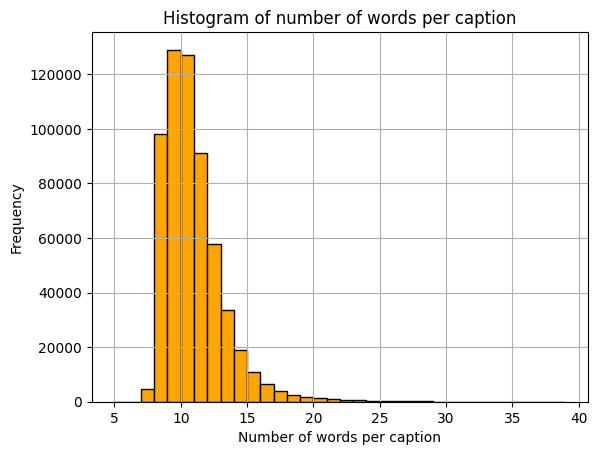

In [52]:
plt.hist(len_caption, bins=list(range(5, 40)), color='orange', edgecolor='black')
plt.xlabel('Number of words per caption')
plt.ylabel('Frequency')
plt.title('Histogram of number of words per caption')
plt.grid(True)
plt.show()